<a href="https://colab.research.google.com/github/22518308/recipefinder/blob/master/AIForecast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **AI Weather Forecast**

---



MMUtube video - https://mmutube.mmu.ac.uk/media/AI_Weather_Forcast_Presentation/1_ma956410

# **Mount Drive**

In [ ]:
# mount your Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Install and Import Dependencies**

In [ ]:
# change current working directory
# check we can see the dataset
import os
os.chdir('/content/drive/MyDrive/DisWeatherAI')
os.path.isfile('open-meteo.csv')

False

In [ ]:
# Install any missing packages
!pip install -q xgboost scikit-learn pandas numpy matplotlib seaborn tensorflow
!pip install -q openmeteo-requests requests-cache retry-requests

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from datetime import datetime, timedelta

# Sklearn
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

# XGBoost
import xgboost as xgb

# TensorFlow / Keras (for LSTM)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Aesthetics
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('coolwarm')
COLORS = {'rf': '#2196F3', 'gb': '#4CAF50', 'xgb': '#FF9800', 'lstm': '#E91E63', 'actual': '#607D8B'}


# **Data - Load or Gernerate Historical weather data**
This cell fetched historical daily weather from Open-Meteo API

Set USE_API to True for Open-Mateo or False for synthetic data

Synthetic data is usefull for testing

Change LATITUDE/LONGITUDE to forecast different locations

A big part of this data was used from the Open-Mateo website - https://open-meteo.com/en/docs

In [ ]:
import openmeteo_requests
import requests_cache
from retry_requests import retry

# CONFIG  - edit these as needed

USE_API       = True  # False = use synthetic data instead
LATITUDE      = 52.52 # Your location latitude
LONGITUDE     = 13.41 # Your location longitude
START_DATE    = '2015-01-01' # Historical start date
END_DATE      = '2024-12-31' # Historical end date
TARGET_COL    = 'precipitation' # Column to predict
FORECAST_DAYS = 7 # How many days ahead to forecast
RANDOM_STATE  = 42


def fetchOpenMeteo(latitude, longitude, startDate, endDate):
    """
    Fetch daily historical weather from the Open-Meteo archive API
    and return a clean DataFrame with standardised column names.
    """
    cacheSession = requests_cache.CachedSession('.cache', expire_after=-1)
    retrySession = retry(cacheSession, retries=5, backoff_factor=0.2)
    openmeteo    = openmeteo_requests.Client(session=retrySession)

    url = 'https://archive-api.open-meteo.com/v1/archive'
    params = {
        'latitude':   latitude,
        'longitude':  longitude,
        'start_date': startDate,
        'end_date':   endDate,
        'daily': [
            'temperature_2m_max',
            'temperature_2m_min',
            'precipitation_sum',
            'wind_speed_10m_max',
            'relative_humidity_2m_max',
            'surface_pressure_mean',
            'cloud_cover_mean',
        ],
        'timezone': 'Europe/London',
    }

    print(f'Fetching data for ({latitude}N, {longitude}E) '
          f'from {startDate} to {endDate}...')
    responses = openmeteo.weather_api(url, params=params)
    response  = responses[0]

    print(f'Coordinates : {response.Latitude()}N  {response.Longitude()}E')
    print(f'Elevation   : {response.Elevation()} m asl')
    print(f'Timezone    : {response.Timezone()}')

    daily = response.Daily()

    dateRange = pd.date_range(start=pd.to_datetime(daily.Time(),    unit='s', utc=True), end=pd.to_datetime(daily.TimeEnd(),   unit='s', utc=True), freq=pd.Timedelta(seconds=daily.Interval()), inclusive='left').tz_localize(None)  # strip timezone for compatibility

    varNames = ['temp_max', 'temp_min', 'precipitation', 'wind_speed', 'humidity', 'pressure', 'cloud_cover']

    data = {'date': dateRange}
    for idx, name in enumerate(varNames):
        try:
            data[name] = daily.Variables(idx).ValuesAsNumpy()
        except Exception:
            print(f'  Warning: could not load variable {name}, filling with NaN')
            data[name] = float('nan')

    df = pd.DataFrame(data)

    # Derive temp_mean if not available
    df['temp_mean'] = (df['temp_max'] + df['temp_min']) / 2

    # Fill any missing columns with neutral defaults
    defaults = {'humidity': 70.0, 'pressure': 1013.0, 'cloud_cover': 50.0, 'wind_speed': 10.0, 'precipitation': 0.0}
    for col, val in defaults.items():
        if df[col].isna().all():
            df[col] = val
            print(f'  {col} was empty, defaulted to {val}')

    df = df.dropna(subset=['date', 'temp_max']).reset_index(drop=True)
    return df


def generate_synthetic_weather(nDays=3650, start='2015-01-01', seed=42):
    # Generate realistic synthetic weather data spanning 10 years
    np.random.seed(seed)
    dates     = pd.date_range(start=start, periods=nDays, freq='D')
    t         = np.arange(nDays)
    season    = np.sin(2 * np.pi * t / 365.25)
    tempMean  = 11 + 8 * season + np.random.normal(0, 2.5, nDays)
    tempRange = 5  + 3 * np.abs(season) + np.random.exponential(1.5, nDays)
    df = pd.DataFrame({
        'date':          dates,
        'temp_max': np.round(tempMean + tempRange / 2, 1),
        'temp_min': np.round(tempMean - tempRange / 2, 1),
        'temp_mean': np.round(tempMean, 1),
        'humidity': np.round(np.clip(70 - 15*season + np.random.normal(0,8,nDays), 20, 100), 1),
        'pressure': np.round(1013 + 5*np.sin(2*np.pi*t/30) + np.random.normal(0,6,nDays), 1),
        'wind_speed': np.round(np.clip(15 + 8*np.abs(season) + np.random.exponential(5,nDays), 0, 90), 1),
        'precipitation': np.round(np.random.binomial(1, 0.4-0.15*season, nDays) * np.random.exponential(5,nDays), 1),
        'cloud_cover': np.round(np.clip(55 - 20*season + np.random.normal(0,15,nDays), 0, 100), 1),
    })
    return df


if USE_API:
    df = fetchOpenMeteo(LATITUDE, LONGITUDE, START_DATE, END_DATE)
else:
    df = generate_synthetic_weather()
    print(f'Generated synthetic data: {df.shape[0]} rows')

print(f'\nDataset: {df.shape[0]} rows | Columns: {list(df.columns)}')
print(f'Date range: {df["date"].min().date()} to {df["date"].max().date()}')
df.head()

Fetching data for (52.52N, 13.41E) from 2015-01-01 to 2024-12-31...
Coordinates : 52.5483283996582N  13.407821655273438E
Elevation   : 38.0 m asl
Timezone    : b'Europe/London'

Dataset: 3653 rows | Columns: ['date', 'temp_max', 'temp_min', 'precipitation', 'wind_speed', 'humidity', 'pressure', 'cloud_cover', 'temp_mean']
Date range: 2014-12-31 to 2024-12-30


,date,temp_max,temp_min,precipitation,wind_speed,humidity,pressure,cloud_cover,temp_mean
0,2014-12-31 23:00:00,4.389,0.939,0.0,19.615870,96.204521,1025.999512,65.083336,2.664
1,2015-01-01 23:00:00,7.489,1.639,2.4,30.472675,88.785332,1013.995605,78.208336,4.564
2,2015-01-02 23:00:00,5.089,2.939,0.2,30.293522,84.548996,1012.479065,84.125000,4.014
3,2015-01-03 23:00:00,4.239,1.339,0.0,25.407431,85.166199,1015.955139,45.125000,2.789
4,2015-01-04 23:00:00,3.689,1.089,5.5,26.208395,98.944748,1021.784180,97.625000,2.389


# **Exploratory Data Analysis**

Print statistic summary of the raw dataset to check for obious issues like missing values, unrealistc ranges, etc.

In [ ]:
print('Dataset Summary')
print(df.describe().round(2))
print(f'\nDate range: {df["date"].min().date()} → {df["date"].max().date()}')
print(f'Missing values:\n{df.isnull().sum()}')

Dataset Summary
                                date  temp_max  temp_min  precipitation  \
count                           3653   3653.00   3653.00        3653.00   
mean   2019-12-31 23:00:00.000000256     14.75      6.96           1.65   
min              2014-12-31 23:00:00     -7.25    -14.95           0.00   
25%              2017-07-01 23:00:00      7.70      1.55           0.00   
50%              2019-12-31 23:00:00     14.40      6.79           0.20   
75%              2022-07-01 23:00:00     21.65     12.65           1.90   
max              2024-12-30 23:00:00     37.65     23.70         108.20   
std                              NaN      8.66      6.83           3.71   

       wind_speed  humidity  pressure  cloud_cover  temp_mean  
count     3653.00   3653.00   3653.00      3653.00    3653.00  
mean        19.43     90.25   1011.07        66.38      10.85  
min          3.96     42.47    969.40         0.00     -10.62  
25%         14.51     87.06   1005.70        49.42  

# **Time series plot**

Showing multiple variables changing over time

Standard way of presenting weath and climate data in meteorology

Call spot relationships between variables

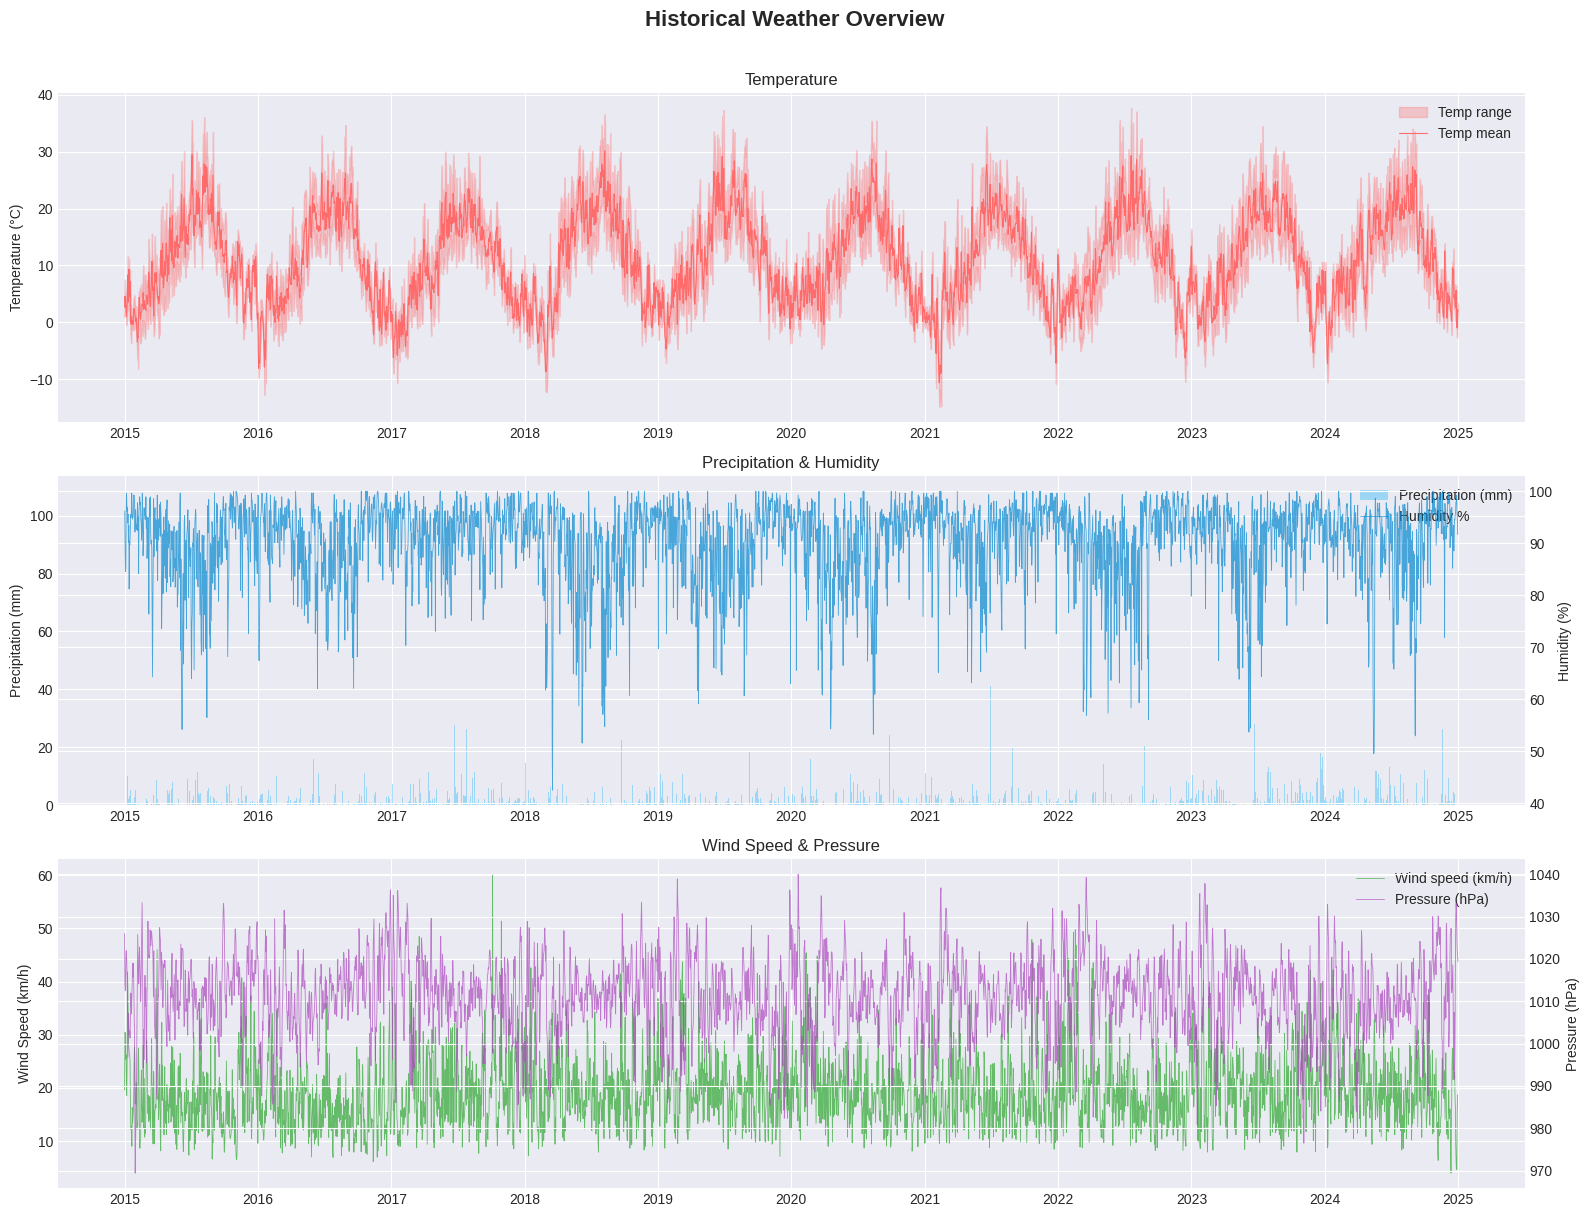

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12))
fig.suptitle('Historical Weather Overview', fontsize=16, fontweight='bold', y=1.01)

# Temperature
ax = axes[0]
ax.fill_between(df['date'], df['temp_min'], df['temp_max'], alpha=0.3, color='#FF6B6B', label='Temp range')
ax.plot(df['date'], df['temp_mean'], color='#FF6B6B', linewidth=0.8, label='Temp mean')
ax.set_ylabel('Temperature (°C)')
ax.legend(loc='upper right')
ax.set_title('Temperature')

# Humidity & Precipitation
ax2 = axes[1]
ax2.bar(df['date'], df['precipitation'], color='#4FC3F7', alpha=0.5, width=1, label='Precipitation (mm)')
ax2b = ax2.twinx()
ax2b.plot(df['date'], df['humidity'], color='#0288D1', linewidth=0.6, alpha=0.7, label='Humidity %')
ax2.set_ylabel('Precipitation (mm)')
ax2b.set_ylabel('Humidity (%)')
ax2.set_title('Precipitation & Humidity')
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

# Wind & Pressure
ax3 = axes[2]
ax3.plot(df['date'], df['wind_speed'], color='#66BB6A', linewidth=0.6, label='Wind speed (km/h)')
ax3b = ax3.twinx()
ax3b.plot(df['date'], df['pressure'], color='#AB47BC', linewidth=0.6, alpha=0.7, label='Pressure (hPa)')
ax3.set_ylabel('Wind Speed (km/h)')
ax3b.set_ylabel('Pressure (hPa)')
ax3.set_title('Wind Speed & Pressure')
lines1, labels1 = ax3.get_legend_handles_labels()
lines2, labels2 = ax3b.get_legend_handles_labels()
ax3.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('weather_overview.png', dpi=150, bbox_inches='tight')
plt.show()

# **HeatMap / Time series Plot**

To comfirm seasonal pattern in the data before moedelling

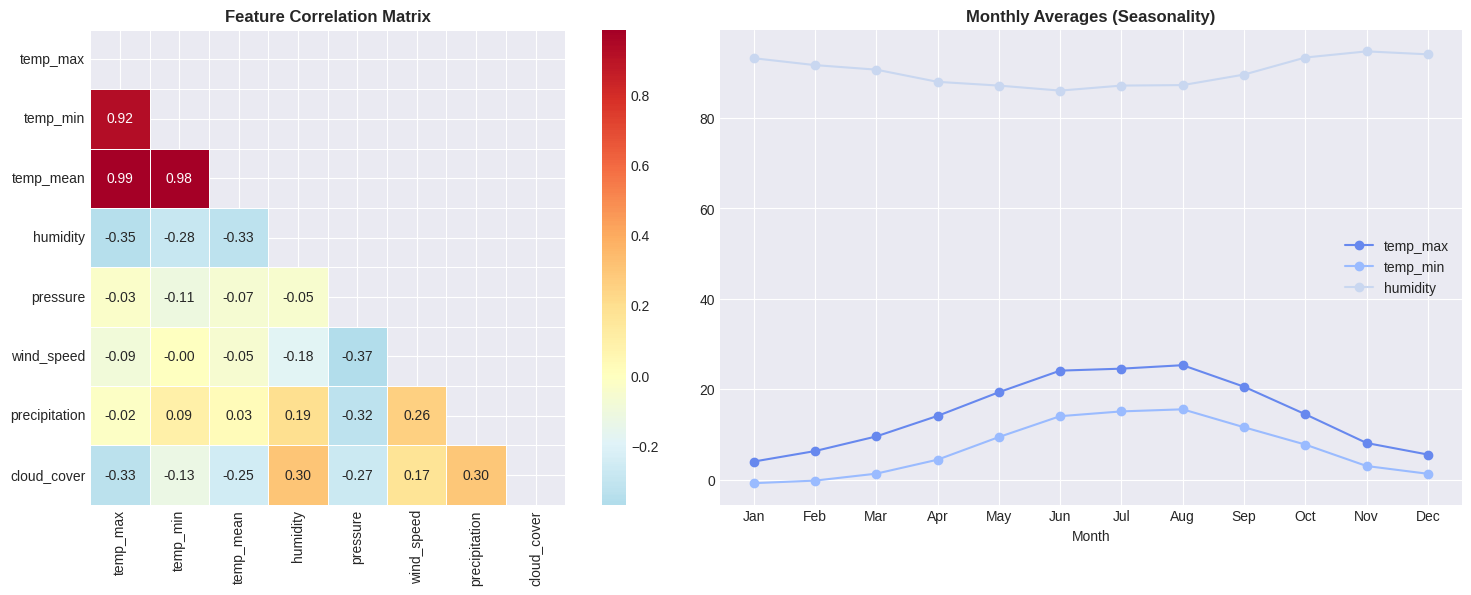

In [ ]:
# Correlation heatmap
numericCols = ['temp_max','temp_min','temp_mean','humidity','pressure','wind_speed','precipitation','cloud_cover']
available = [c for c in numericCols if c in df.columns]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

corr = df[available].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu_r', center=0, ax=ax1, square=True, linewidths=0.5)
ax1.set_title('Feature Correlation Matrix', fontweight='bold')

# Monthly seasonality
df['month'] = df['date'].dt.month
monthly = df.groupby('month')[available].mean()
monthly[['temp_max','temp_min','humidity']].plot(ax=ax2, marker='o')
ax2.set_xlabel('Month')
ax2.set_title('Monthly Averages (Seasonality)', fontweight='bold')
ax2.set_xticks(range(1,13))
ax2.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
ax2.legend()

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()

# **Feature Engineering**

Take raw data and create a new columns that make it easier for the model to find patterns.

In [ ]:
def engineer_features(df, target=TARGET_COL, lagDays=[1,2,3,7,14,30]):
    # Create time-series features from raw weather data
    df = df.copy()
    df = df.sort_values('date').reset_index(drop=True)

    #  Calendar features
    df['day_of_year'] = df['date'].dt.dayofyear
    df['day_of_week'] = df['date'].dt.dayofweek
    df['month'] = df['date'].dt.month
    df['year'] = df['date'].dt.year
    df['quarter'] = df['date'].dt.quarter
    df['week_of_year'] = df['date'].dt.isocalendar().week.astype(int)

    #  Cyclical encoding (avoids discontinuity at Dec→Jan, etc.)
    df['sin_doy'] = np.sin(2 * np.pi * df['day_of_year'] / 365.25)
    df['cos_doy'] = np.cos(2 * np.pi * df['day_of_year'] / 365.25)
    df['sin_mon'] = np.sin(2 * np.pi * df['month'] / 12)
    df['cos_mon'] = np.cos(2 * np.pi * df['month'] / 12)
    df['sin_dow'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
    df['cos_dow'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

    #  Lag features
    lagCols = [target, 'humidity', 'pressure', 'wind_speed', 'precipitation']
    lagCols = [c for c in lagCols if c in df.columns]
    for col in lagCols:
        for lag in lagDays:
            df[f'{col}_lag{lag}'] = df[col].shift(lag)

    #  Rolling statistics
    windows = [7, 14, 30]
    rollCols = [target, 'humidity', 'precipitation']
    rollCols = [c for c in rollCols if c in df.columns]
    for col in rollCols:
        for w in windows:
            df[f'{col}_roll{w}_mean'] = df[col].shift(1).rolling(w).mean()
            df[f'{col}_roll{w}_std']  = df[col].shift(1).rolling(w).std()
        df[f'{col}_roll7_min']  = df[col].shift(1).rolling(7).min()
        df[f'{col}_roll7_max']  = df[col].shift(1).rolling(7).max()

    #  Interaction / derived features
    if 'temp_max' in df.columns and 'temp_min' in df.columns:
        df['tempRange'] = df['temp_max'] - df['temp_min']
    if 'humidity' in df.columns and 'pressure' in df.columns:
        df['humidity_pressure'] = df['humidity'] * df['pressure'] / 1000
    if 'wind_speed' in df.columns and 'cloud_cover' in df.columns:
        df['wind_cloud'] = df['wind_speed'] * df['cloud_cover'] / 100

    # Drop rows with NaN from lag/rolling
    df = df.dropna().reset_index(drop=True)
    print(f' Feature engineering complete: {df.shape[1]} total features, {df.shape[0]} usable rows')
    return df

dfFeat = engineer_features(df)
dfFeat.head(3)

 Feature engineering complete: 64 total features, 3623 usable rows


,date,temp_max,temp_min,precipitation,wind_speed,humidity,pressure,cloud_cover,temp_mean,month,...,humidity_roll7_std,humidity_roll14_mean,humidity_roll14_std,humidity_roll30_mean,humidity_roll30_std,humidity_roll7_min,humidity_roll7_max,tempRange,humidity_pressure,wind_cloud
0,2015-01-30 23:00:00,1.039,-0.761,2.0,18.806337,96.432915,974.413330,92.291664,0.139,1,...,2.403490,96.329316,2.071752,94.043246,4.619512,92.154999,99.284424,1.80,93.965515,17.356682
1,2015-01-31 23:00:00,1.789,-0.461,0.3,16.923830,92.965157,983.588623,87.750000,0.664,1,...,2.302218,96.395073,2.058393,94.050859,4.623383,92.154999,99.284424,2.25,91.439468,14.850660
2,2015-02-01 23:00:00,2.839,-1.361,0.2,20.966715,92.610573,989.691406,72.041664,0.739,2,...,2.678433,96.254825,2.226056,94.190187,4.521082,92.154999,99.284424,4.20,91.655891,15.104771


# **Train / Test Split**

Seoerate the dataset into imput features X and the target variable Y

Drop columns that would leake information like temp_min/max

In [ ]:
# Features and target
dropCols = ['date', TARGET_COL, 'temp_min', 'temp_mean']  # drop leaky cols
dropCols = [c for c in dropCols if c in dfFeat.columns and c != TARGET_COL]
featureCols = [c for c in dfFeat.columns if c not in ['date', TARGET_COL]]

X = dfFeat[featureCols]
y = dfFeat[TARGET_COL]
datesAll = dfFeat['date']

# Chronological 80/20 split never shuffle time series data
# Shuffling would leak future values into training and make the results less honest
# high accuracy sores that would not hold up in real use
splitIdx = int(len(X) * 0.80)
X_train, X_test = X.iloc[:splitIdx], X.iloc[splitIdx:]
y_train, y_test = y.iloc[:splitIdx], y.iloc[splitIdx:]
datesTest = datesAll.iloc[splitIdx:]

print(f'Training set : {X_train.shape[0]} days  ({datesAll.iloc[0].date()} → {datesAll.iloc[splitIdx-1].date()})')
print(f'Test set : {X_test.shape[0]} days   ({datesAll.iloc[splitIdx].date()} → {datesAll.iloc[-1].date()})')
print(f'Features : {X_train.shape[1]}')

Training set : 2898 days  (2015-01-30 → 2023-01-05)
Test set : 725 days   (2023-01-06 → 2024-12-30)
Features : 62


# **Train Multiple ML Models**

Helper function that computes MAE, RMSE and R^2 for any model

MAE = arveage error in degree

RMSE = prenalise large errors more heavily

R^2 = proportion of variance (1 perfect, 0 basically outputing mean)

In [ ]:
def evaluate(name, yTrue, yPred, color):
    mae  = mean_absolute_error(yTrue, yPred)
    rmse = np.sqrt(mean_squared_error(yTrue, yPred))
    r2   = r2_score(yTrue, yPred)
    print(f'[{name:20s}]  MAE={mae:.2f}°C   RMSE={rmse:.2f}°C   R²={r2:.4f}')
    return {'name': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'pred': yPred, 'color': color}

results = {}

# Random Forest
# Ensemble of decision tree trained on random subsets of the data
# Robust and a good baseline
print('Training Random Forest')
rf = RandomForestRegressor(n_estimators=300, max_depth=12, min_samples_leaf=3, n_jobs=-1, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)
results['rf'] = evaluate('Random Forest', y_test, rf.predict(X_test), COLORS['rf'])

# Gradient Boosting
# Builds tree sequentially each one correcting the errors of the previous
# Slowet to train but more accurate than Random Forest
print('Training Gradient Boosting')
gb = GradientBoostingRegressor(n_estimators=400, learning_rate=0.05, max_depth=5, subsample=0.8, random_state=RANDOM_STATE)
gb.fit(X_train, y_train)
results['gb'] = evaluate('Gradient Boosting', y_test, gb.predict(X_test), COLORS['gb'])

# XGBoost
# A more optimies version of Gradient Boosting
# Typically stronget model
print('Training XGBoost')
xgbModel = xgb.XGBRegressor(n_estimators=500, learning_rate=0.04, max_depth=6, subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE, verbosity=0)
xgbModel.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
results['xgb'] = evaluate('XGBoost', y_test, xgbModel.predict(X_test), COLORS['xgb'])

Training Random Forest
[Random Forest       ]  MAE=1.66°C   RMSE=3.08°C   R²=0.3223
Training Gradient Boosting
[Gradient Boosting   ]  MAE=1.72°C   RMSE=3.18°C   R²=0.2791
Training XGBoost
[XGBoost             ]  MAE=1.67°C   RMSE=3.06°C   R²=0.3294


# **LSTM Neutal Netowork**

LSTM requires 3D input shape samples, timesteps and features

We scale all values 0 to 1 first (makes the neural network train better)

On normalised data than on raw temperature/pressure values

In [ ]:
#  Prepare data for LSTM
# LSTM needs shape (samples, timesteps, features)
SEQUENCE_LEN = 30   # use 30 past days as context window

# Scale features
scalerX = MinMaxScaler()
scalerY = MinMaxScaler()

xScaled = scalerX.fit_transform(X)
yScaled = scalerY.fit_transform(y.values.reshape(-1, 1)).flatten()

# Slide a window of SEQUENCE_LEN days across the dataset to make
# imput/output pairs, each imput is 30 consecutive rows of features
# each output is the target value on the day after the window ends

def make_sequences(X_arr, y_arr, seq_len):
    Xs, ys = [], []
    for i in range(len(X_arr) - seq_len):
        Xs.append(X_arr[i : i + seq_len])
        ys.append(y_arr[i + seq_len])
    return np.array(Xs), np.array(ys)

xSeq, ySeq = make_sequences(xScaled, yScaled, SEQUENCE_LEN)

# Same 80/20 split offset by SEQUENCE_LEN
splitSeq = int(len(xSeq) * 0.80)
xTrSeq, xTeSeq = xSeq[:splitSeq], xSeq[splitSeq:]
yTrSeq, yTeSeq = ySeq[:splitSeq], ySeq[splitSeq:]

print(f'LSTM sequences Train: {xTrSeq.shape}, Test: {xTeSeq.shape}')

LSTM sequences Train: (2874, 30, 62), Test: (719, 30, 62)


# **Build the LSTM model architecture**

2 LSTM layers with dropout between then so we dont get overfitting

EarlyStopping halts training if validation loss stops improving preventing the model from memorising the training data

In [ ]:
#  Build LSTM model
tf.random.set_seed(RANDOM_STATE)

nFeatures = xTrSeq.shape[2]

lstmModel = Sequential([ LSTM(128, input_shape=(SEQUENCE_LEN, nFeatures), return_sequences=True), BatchNormalization(), Dropout(0.25), LSTM(64, return_sequences=False), BatchNormalization(), Dropout(0.2), Dense(32, activation='relu'), Dense(1)])

# Huber loss is less sensitive to outlies than MSE making it a good choice
# for weather data which has the occasional spike
lstmModel.compile(optimizer=Adam(learning_rate=0.001), loss='huber', metrics=['mae'])
lstmModel.summary()

callbacks = [EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True), ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, verbose=1)]

history = lstmModel.fit(xTrSeq, yTrSeq, epochs=100, batch_size=64, validation_split=0.15, callbacks=callbacks, verbose=1)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 30, 128)        │        97,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 30, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 150,081 (586.25 KB)

 Trainable params: 149,697 (584.75 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 22s 296ms/step - loss: 0.1649 - mae: 0.4511 - val_loss: 0.0021 - val_mae: 0.0554 - learning_rate: 0.0010
Epoch 2/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 12s 319ms/step - loss: 0.0729 - mae: 0.2991 - val_loss: 0.0015 - val_mae: 0.0448 - learning_rate: 0.0010
Epoch 3/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 110ms/step - loss: 0.0416 - mae: 0.2291 - val_loss: 0.0020 - val_mae: 0.0483 - learning_rate: 0.0010
Epoch 4/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 7s 175ms/step - loss: 0.0297 - mae: 0.1950 - val_loss: 0.0091 - val_mae: 0.1073 - learning_rate: 0.0010
Epoch 5/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 8s 106ms/step - loss: 0.0218 - mae: 0.1629 - val_loss: 0.0082 - val_mae: 0.1136 - learning_rate: 0.0010
Epoch 6/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 6s 150ms/step - loss: 0.0175 - mae: 0.1466 - val_loss: 0.0080 - val_mae: 0.1138 - learning_rate: 0.0010
Epoch 7/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 5s 130ms/step - loss: 0.0120 - mae: 0.1218 - val_loss: 0.0048 - val_mae: 0.0809 - learning_rate: 0.00

[LSTM Neural Net     ]  MAE=3.11°C   RMSE=4.37°C   R²=-0.3569


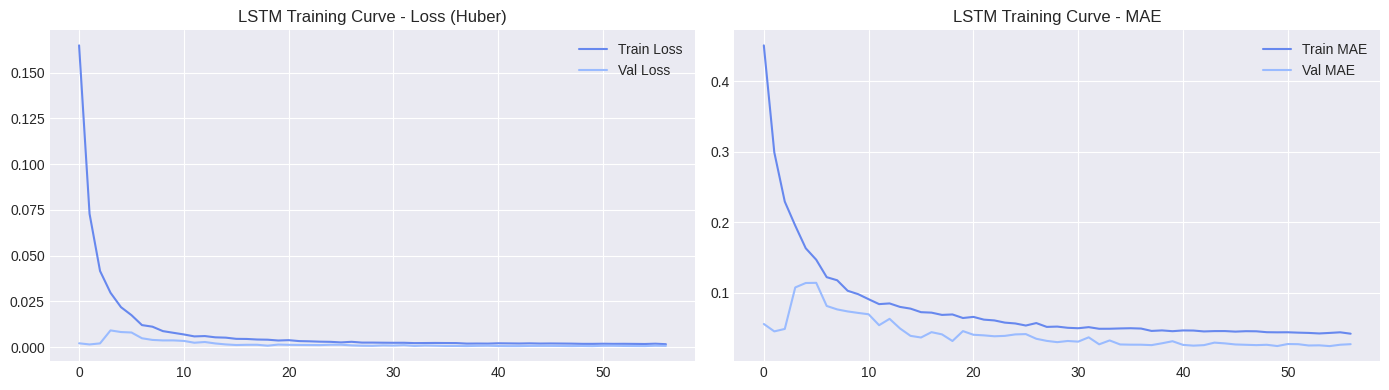

In [ ]:
# Evaluate LSTM
lstmPredScaled = lstmModel.predict(xTeSeq, verbose=0).flatten()
lstmPred = scalerY.inverse_transform(lstmPredScaled.reshape(-1, 1)).flatten()

# Align y_test with LSTM output using splitSeq (the LSTM-specific split point)
# splitSeq accounts for the SEQUENCE_LEN offset applied when building sequences
yTestLstm = y.values[splitSeq + SEQUENCE_LEN : splitSeq + SEQUENCE_LEN + len(lstmPred)]

# Safety check trim to shortest if there's still a mismatch
minLen = min(len(yTestLstm), len(lstmPred))
yTestLstm = yTestLstm[:minLen]
lstmPred  = lstmPred[:minLen]

results['lstm'] = evaluate('LSTM Neural Net', yTestLstm, lstmPred, COLORS['lstm'])

# Training curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(history.history['loss'], label='Train Loss')
ax1.plot(history.history['val_loss'], label='Val Loss')
ax1.set_title('LSTM Training Curve - Loss (Huber)')
ax1.legend()
ax2.plot(history.history['mae'], label='Train MAE')
ax2.plot(history.history['val_mae'], label='Val MAE')
ax2.set_title('LSTM Training Curve - MAE')
ax2.legend()
plt.tight_layout()
plt.savefig('lstm_training.png', dpi=150, bbox_inches='tight')
plt.show()

# **Model Comparison and Evaluation**

Build a summary table comparing the 4 models

Best model (Lowest RMSE) is used for the 7 day forecast

In [ ]:
#  Summary table
metricsDF = pd.DataFrame([{'Model': v['name'], 'MAE (°C)': round(v['MAE'],3),'RMSE (°C)': round(v['RMSE'],3), 'R²': round(v['R2'],4)}
    for v in results.values()
]).sort_values('RMSE (°C)')

print('\n MODEL COMPARISON')
print(metricsDF.to_string(index=False))

bestModelKey = metricsDF.iloc[0]['Model']
print(f'\n Best model (lowest RMSE): {bestModelKey}')


 MODEL COMPARISON
            Model  MAE (°C)  RMSE (°C)      R²
          XGBoost     1.669      3.065  0.3294
    Random Forest     1.661      3.081  0.3223
Gradient Boosting     1.716      3.177  0.2791
  LSTM Neural Net     3.109      4.366 -0.3569

 Best model (lowest RMSE): XGBoost


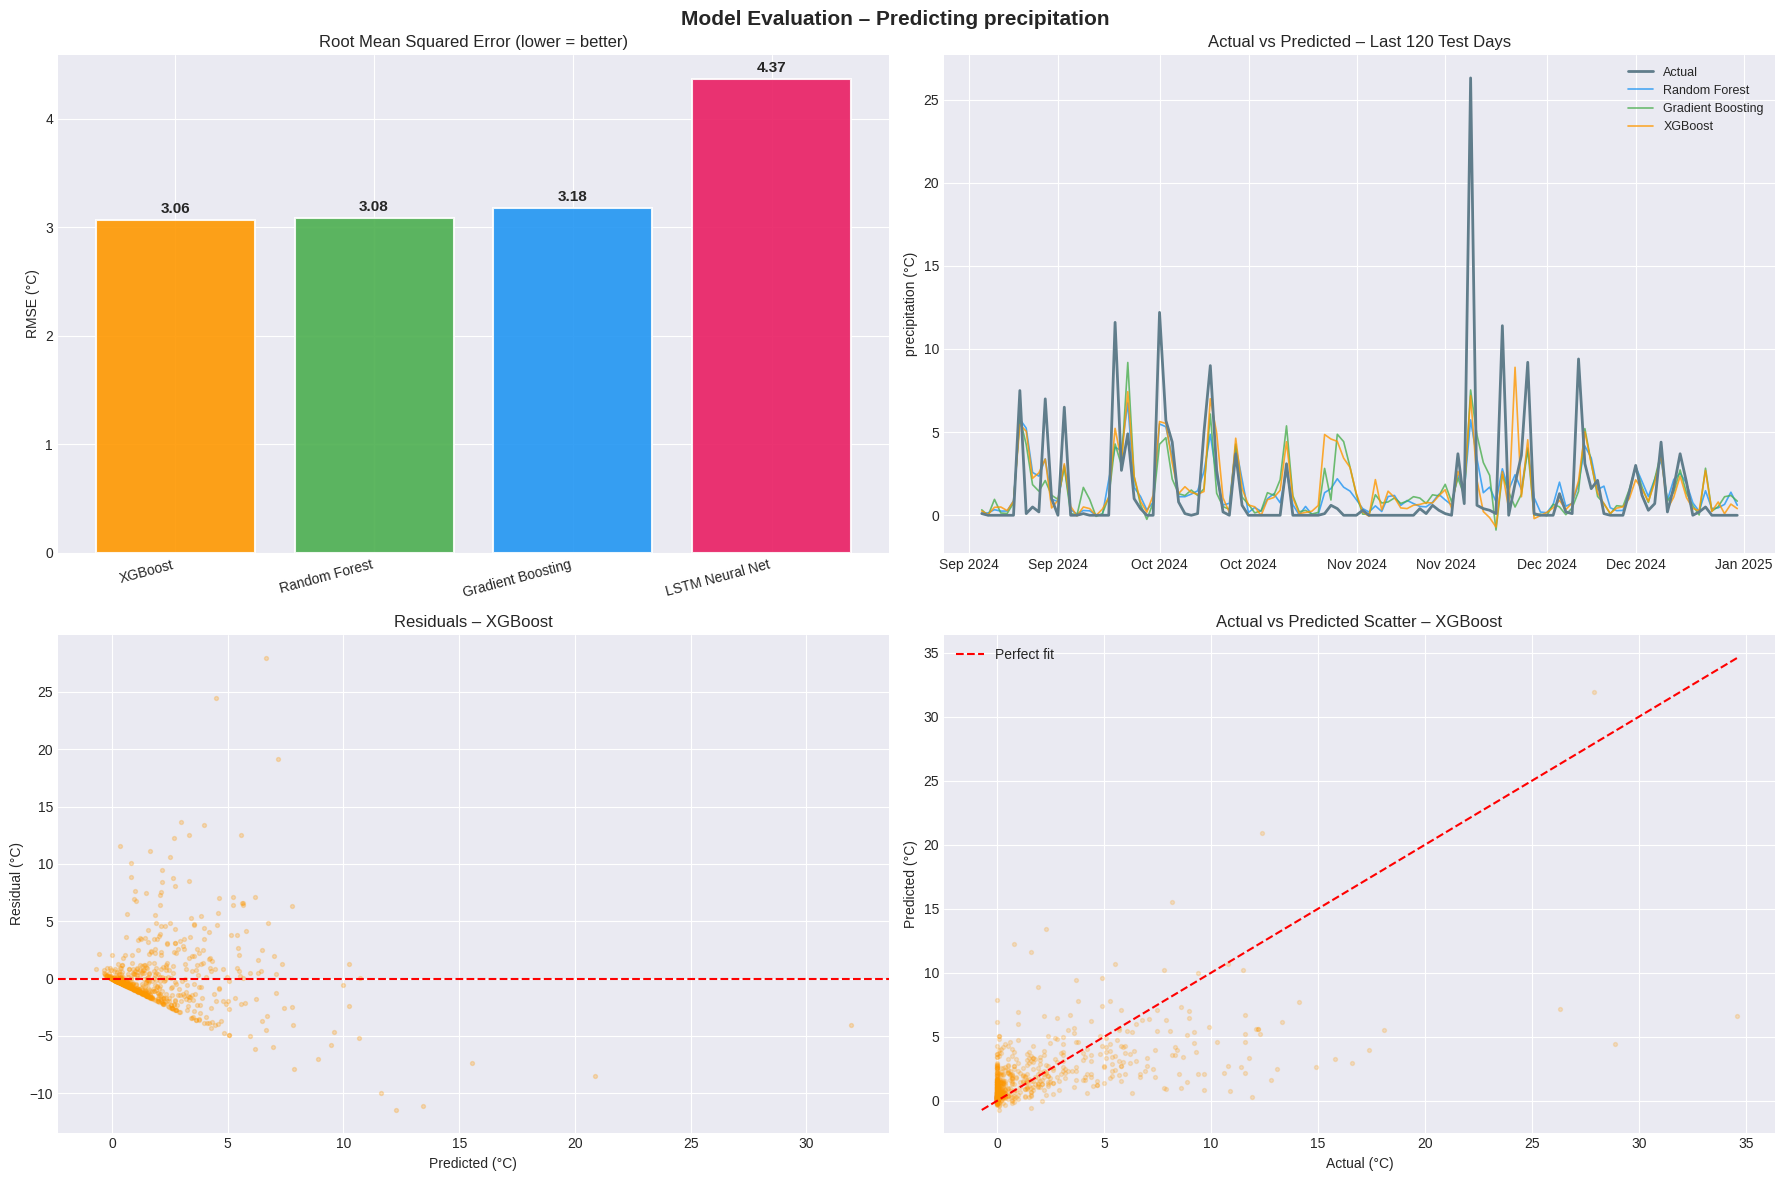

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle(f'Model Evaluation – Predicting {TARGET_COL}', fontsize=15, fontweight='bold')

#  Bar chart metrics
ax = axes[0, 0]
x = np.arange(len(metricsDF))
bars = ax.bar(x, metricsDF['RMSE (°C)'], color=[COLORS.get(k, '#888') for k in ['xgb','gb','rf','lstm']][:len(metricsDF)], edgecolor='white', linewidth=1.5, alpha=0.9)
ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=11, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metricsDF['Model'], rotation=15, ha='right')
ax.set_ylabel('RMSE (°C)')
ax.set_title('Root Mean Squared Error (lower = better)')

#  Actual vs Predicted last 120 days (tree models)
ax = axes[0, 1]
ax.plot(datesTest.values[-120:], y_test.values[-120:], color=COLORS['actual'], linewidth=2, label='Actual', zorder=5)
for key in ['rf', 'gb', 'xgb']:
    r = results[key]
    ax.plot(datesTest.values[-120:], r['pred'][-120:], color=r['color'], linewidth=1.2, alpha=0.8, label=r['name'])
ax.set_title('Actual vs Predicted – Last 120 Test Days')
ax.set_ylabel(f'{TARGET_COL} (°C)')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

#  Residuals best tree model
ax = axes[1, 0]
bestKey = min(['rf','gb','xgb'], key=lambda k: results[k]['RMSE'])
residuals = y_test.values - results[bestKey]['pred']
ax.scatter(results[bestKey]['pred'], residuals, alpha=0.25, s=8, color=results[bestKey]['color'])
ax.axhline(0, color='red', linewidth=1.5, linestyle='--')
ax.set_xlabel('Predicted (°C)')
ax.set_ylabel('Residual (°C)')
ax.set_title(f'Residuals – {results[bestKey]["name"]}')

#  Scatter actual vs predicted (best)
ax = axes[1, 1]
ax.scatter(y_test.values, results[bestKey]['pred'], alpha=0.2, s=8, color=results[bestKey]['color'])
lims = [min(y_test.min(), results[bestKey]['pred'].min()), max(y_test.max(), results[bestKey]['pred'].max())]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect fit')
ax.set_xlabel('Actual (°C)')
ax.set_ylabel('Predicted (°C)')
ax.set_title(f'Actual vs Predicted Scatter – {results[bestKey]["name"]}')
ax.legend()

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

# **Future Forecast Next n Days**

Use an iteratice prediction loop each days prediction is fed back as lag feature for the next day

In [ ]:
# Safety check - ensure bestTree is defined
if 'bestTree' not in dir():
    modelMap    = {'rf': rf, 'gb': gb, 'xgb': xgbModel}
    bestTreeKey = min(['rf', 'gb', 'xgb'], key=lambda k: results[k]['RMSE'])
    bestTree    = modelMap[bestTreeKey]
    print(f'bestTree set to: {results[bestTreeKey]["name"]}')

def iterative_forecast(model, dfFeat, featureCols, targetCol, nDays=7):

    # Iteratively forecast nDays into the future.
    # All lag features are shifted forward each step to avoid the
    # 'stuck prediction' bug where every day returns the same value.

    # Work on a copy of the full feature history so we can shift lags properly
    history = dfFeat[featureCols].copy().reset_index(drop=True)
    lastDate = dfFeat['date'].iloc[-1]
    forecasts = []

    for i in range(1, nDays + 1):
        # Use the last row as the input for this prediction
        lastRow = history.iloc[-1].copy()

        # Update calendar / cyclical features for the new forecast date
        forecastDate = lastDate + timedelta(days=i)
        doy = forecastDate.timetuple().tm_yday
        if 'sin_doy' in lastRow.index: lastRow['sin_doy'] = np.sin(2*np.pi*doy/365.25)
        if 'cos_doy' in lastRow.index: lastRow['cos_doy'] = np.cos(2*np.pi*doy/365.25)
        if 'sin_mon' in lastRow.index: lastRow['sin_mon'] = np.sin(2*np.pi*forecastDate.month/12)
        if 'cos_mon' in lastRow.index: lastRow['cos_mon'] = np.cos(2*np.pi*forecastDate.month/12)
        if 'sin_dow' in lastRow.index: lastRow['sin_dow'] = np.sin(2*np.pi*forecastDate.weekday()/7)
        if 'cos_dow' in lastRow.index: lastRow['cos_dow'] = np.cos(2*np.pi*forecastDate.weekday()/7)
        if 'month' in lastRow.index: lastRow['month'] = forecastDate.month
        if 'day_of_year' in lastRow.index: lastRow['day_of_year'] = doy
        if 'day_of_week' in lastRow.index: lastRow['day_of_week'] = forecastDate.weekday()
        if 'week_of_year' in lastRow.index: lastRow['week_of_year'] = forecastDate.isocalendar()[1]

        # Predict
        predVal = float(model.predict(lastRow.values.reshape(1, -1))[0])
        forecasts.append({'date': forecastDate, f'predicted_{targetCol}': round(predVal, 1)})

        # Build a new row with all lag features properly shifted
        # lag1 <- prediction, lag2 <- old lag1, lag3 <- old lag2, etc.
        newRow = lastRow.copy()
        lagCols = sorted(
            [c for c in featureCols if c.startswith(f'{targetCol}_lag')],
            key=lambda c: int(c.split('lag')[1])
        )
        for j in range(len(lagCols) - 1, 0, -1):
            newRow[lagCols[j]] = lastRow[lagCols[j - 1]]
        if len(lagCols) > 0:
            newRow[lagCols[0]] = predVal  # lag1 = latest prediction

        # Append the new row so rolling features update on next iteration
        history = pd.concat([history, newRow.to_frame().T], ignore_index=True)

    return pd.DataFrame(forecasts)


forecastDf = iterative_forecast(bestTree, dfFeat, featureCols, TARGET_COL, nDays=FORECAST_DAYS)

print(f'\n{FORECAST_DAYS}-Day Forecast ({TARGET_COL})')
for _, row in forecastDf.iterrows():
    dayName = row['date'].strftime('%A %d %b %Y')
    temp    = row[f'predicted_{TARGET_COL}']
    label   = 'warm' if temp > 20 else ('mild' if temp > 12 else 'cold')
    print(f'  {dayName:<24}  {temp:+.1f} C  ({label})')


7-Day Forecast (precipitation)
  Tuesday 31 Dec 2024       +0.4 C  (cold)
  Wednesday 01 Jan 2025     +0.4 C  (cold)
  Thursday 02 Jan 2025      +0.4 C  (cold)
  Friday 03 Jan 2025        +0.4 C  (cold)
  Saturday 04 Jan 2025      +0.3 C  (cold)
  Sunday 05 Jan 2025        +0.3 C  (cold)
  Monday 06 Jan 2025        +0.3 C  (cold)


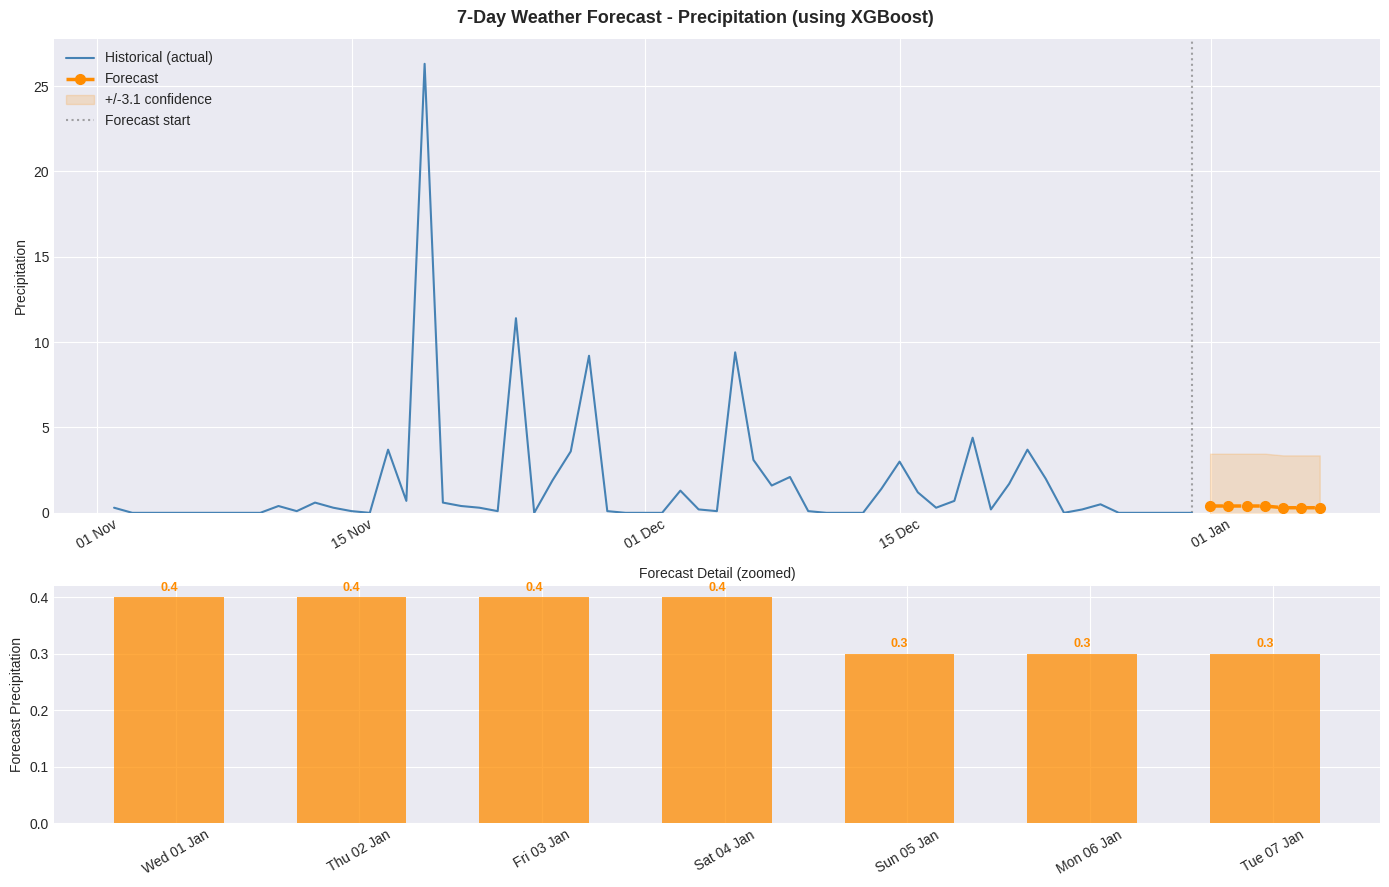

Forecast plot saved to forecast.png


In [ ]:
# Visualise forecast
LOOKBACK_PLOT = 60   # days of history to show for context

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9),
                               gridspec_kw={'height_ratios': [2, 1]})
fig.suptitle(f'7-Day Weather Forecast - {TARGET_COL.replace("_"," ").title()} (using {results[bestTreeKey]["name"]})',
             fontsize=13, fontweight='bold')

# Top panel: historical + forecast
hist = dfFeat[['date', TARGET_COL]].iloc[-LOOKBACK_PLOT:]
ax1.plot(hist['date'], hist[TARGET_COL], color='steelblue', linewidth=1.5, label='Historical (actual)', zorder=3)

ax1.plot(forecastDf['date'], forecastDf[f'predicted_{TARGET_COL}'],color='darkorange', linewidth=2.5, marker='o', markersize=7, linestyle='--', label='Forecast', zorder=4)

rmseVal = results[bestTreeKey]['RMSE']
ax1.fill_between(forecastDf['date'], forecastDf[f'predicted_{TARGET_COL}'] - rmseVal, forecastDf[f'predicted_{TARGET_COL}'] + rmseVal, alpha=0.18, color='darkorange', label=f'+/-{rmseVal:.1f} confidence')

ax1.axvline(dfFeat['date'].iloc[-1], color='gray', linewidth=1.5, linestyle=':', alpha=0.7, label='Forecast start')

ax1.set_ylabel(f'{TARGET_COL.replace("_"," ").title()}')
ax1.legend(loc='upper left')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30)

# Bottom panel forecast only but zoomed in
forecastVals = forecastDf[f'predicted_{TARGET_COL}']
ax2.bar(forecastDf['date'], forecastVals, color='darkorange', alpha=0.75, width=0.6, zorder=3)

# Label each bar
for _, row in forecastDf.iterrows():
    val = row[f'predicted_{TARGET_COL}']
    ax2.text(row['date'], val + forecastVals.max() * 0.03, f'{val:.1f}', ha='center', fontsize=9, fontweight='bold', color='darkorange')

ax2.set_ylabel(f'Forecast {TARGET_COL.replace("_"," ").title()}')
ax2.set_title('Forecast Detail (zoomed)', fontsize=10)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%a %d %b'))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30)

# Set y-axis floor to 0 for precipitationtype variables
if TARGET_COL in ['precipitation', 'wind_speed', 'cloud_cover', 'humidity']:
    ax1.set_ylim(bottom=0)
    ax2.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig('forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print('Forecast plot saved to forecast.png')

# **Summary**



*   Data - 10 years synthetic daily weather or Open-Mateo API
*   Features - Lag features, rolling stats, cyclical calendar encoding, interaction terms
*   Models - Random Forest, Gradient Boosting, XGBoosting, LSTM Neural Network
*    Forecast - Iterative n days ahead prediction with confidance band



